<a href="https://colab.research.google.com/github/LuksDvs/fraude-cartao-credito/blob/main/fraude_cartao_credito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Fraude em Cartão de Crédito
Projeto baseado no dataset creditcard.csv (284.807 transações, 0,172% fraude)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
print("Setup OK")


Setup OK


In [ ]:
DATASET_URL = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

df = pd.read_csv(DATASET_URL)

print(f"Carregado via URL: {DATASET_URL}")
print(f"Shape: {df.shape}")
print(f"Taxa de fraude: {df.Class.mean()*100:.4f}%")
df.head()

Carregado via URL: https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv
Shape: (284807, 31)
Taxa de fraude: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64
Taxa de fraude: 0.1727%

Transações normais: 284315
Transações fraude: 492
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.759061e-12 -8.251130e-13 -9.654937e-13  8.321385e-13   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.8480

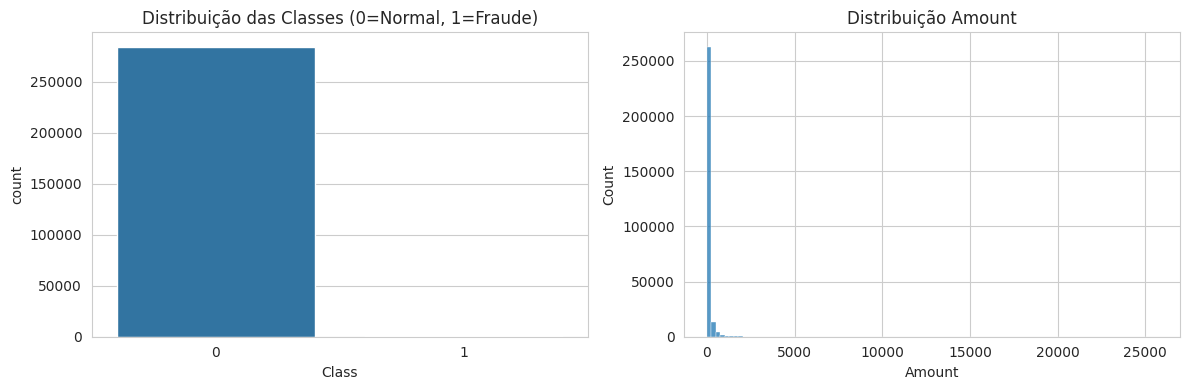

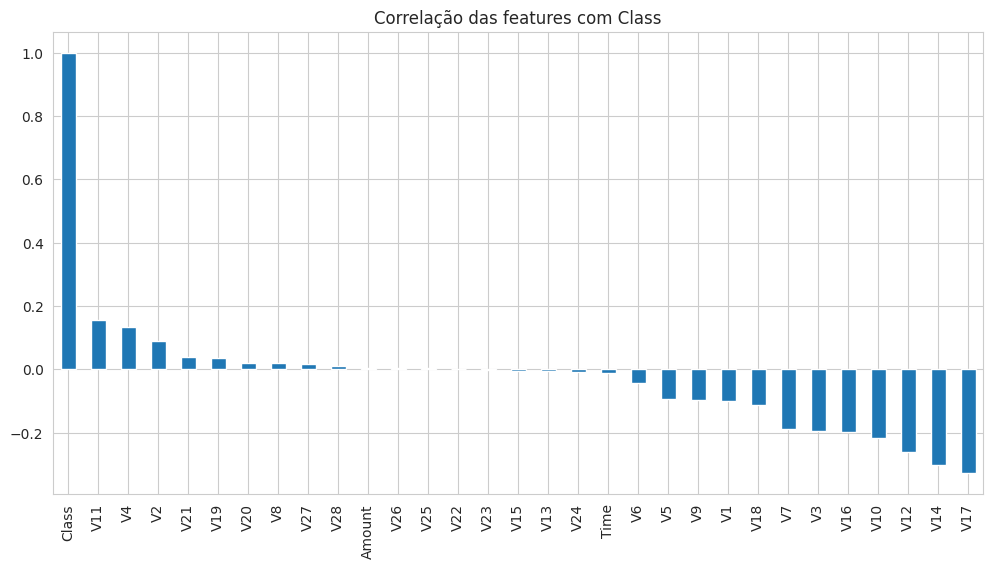

In [ ]:
# Proporção de fraude - ponto central do projeto
fraud_count = df['Class'].value_counts()
print(fraud_count)
print(f"Taxa de fraude: {df.Class.mean()*100:.4f}%")
print(f"\nTransações normais: {fraud_count[0]}")
print(f"Transações fraude: {fraud_count[1]}")

print(df.describe())

# Distribuição
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.countplot(x='Class', data=df, ax=ax[0])
ax[0].set_title('Distribuição das Classes (0=Normal, 1=Fraude)')
sns.histplot(df['Amount'], bins=100, ax=ax[1])
ax[1].set_title('Distribuição Amount')
plt.tight_layout()
plt.show()

# Correlação rápida com a classe
plt.figure(figsize=(12,6))
df.corr(numeric_only=True)['Class'].sort_values(ascending=False).plot(kind='bar')
plt.title('Correlação das features com Class')
plt.show()


In [ ]:
# Feature engineering - ideia da Expert
df['Amount_log'] = np.log1p(df['Amount'])

# Padronização - Time e Amount são as únicas não anonimizadas
scaler = StandardScaler()
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df['Amount_scaled'] = scaler.fit_transform(df[['Amount_log']])

# X e y
cols_to_drop = ['Class', 'Time', 'Amount', 'Amount_log']
# Mantemos V1-V28 + Time_scaled + Amount_scaled
X = df.drop(columns=cols_to_drop)
y = df['Class']

# Split com stratify é obrigatório aqui
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Treino shape: {X_train.shape}")
print(f"Teste shape: {X_test.shape}")
print(f"Treino fraude: {y_train.mean()*100:.4f}%")
print(f"Teste fraude: {y_test.mean()*100:.4f}%")


Treino shape: (199364, 30)
Teste shape: (85443, 30)
Treino fraude: 0.1725%
Teste fraude: 0.1732%


In [ ]:
# Pesos para lidar com desbalanceamento
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Versão leve para rodar rápido no Colab
models = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=30,  # era 100, 30 já basta pra validar
        max_depth=12,      # limita profundidade pra rodar 3x mais rápido
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
}

# XGBoost - COMENTADO pra não travar
# Se quiser depois, descomente e rode: !pip install -q xgboost
# from xgboost import XGBClassifier
# models["XGBoost"] = XGBClassifier(
#     scale_pos_weight=scale_pos_weight,
#     eval_metric='logloss',
#     random_state=42,
#     n_jobs=-1
# )

for name, model in models.items():
    print(f"Treinando {name}...")
    model.fit(X_train, y_train)
    print(f"{name} treinado")


scale_pos_weight: 578.55
Treinando LogisticRegression...
LogisticRegression treinado
Treinando RandomForest...
RandomForest treinado



========== LogisticRegression ==========

--- Threshold: 0.5 ---
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     85295
      Fraude       0.06      0.87      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443

ROC-AUC: 0.9677


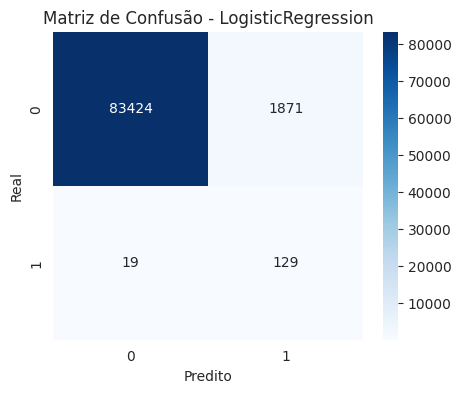

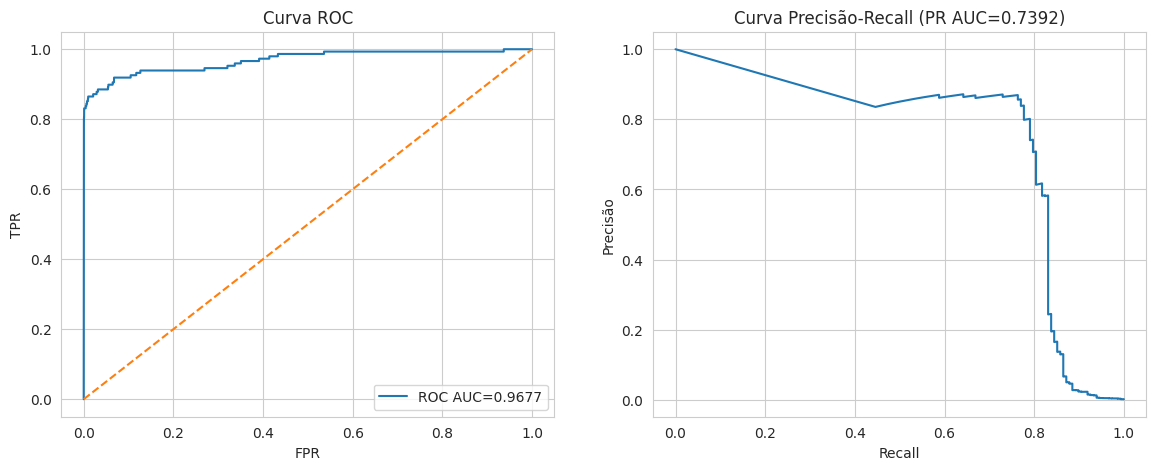


========== RandomForest ==========

--- Threshold: 0.5 ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
      Fraude       0.88      0.76      0.82       148

    accuracy                           1.00     85443
   macro avg       0.94      0.88      0.91     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC: 0.9482


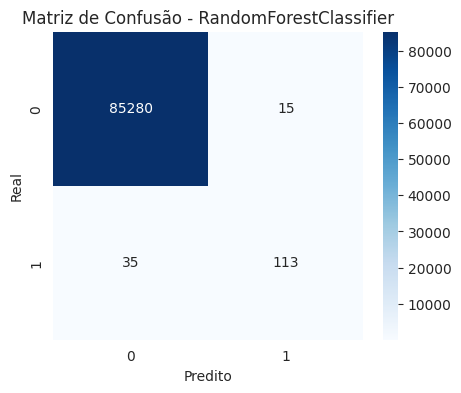

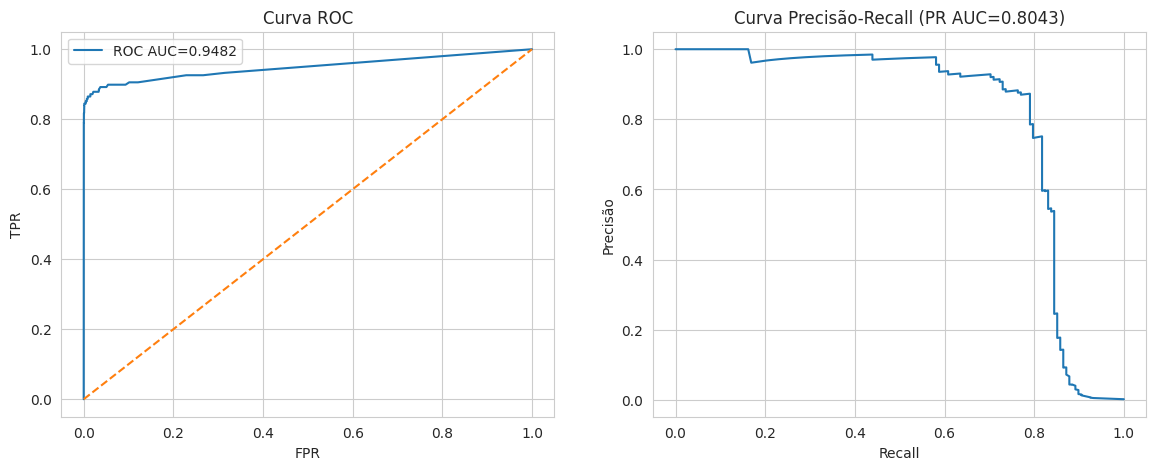

In [ ]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_proba = model.predict_proba(X_test)[:,1]
    y_pred = (y_proba >= threshold).astype(int)

    print(f"\n--- Threshold: {threshold} ---")
    print(classification_report(y_test, y_pred, target_names=['Normal','Fraude']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {model.__class__.__name__}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

    return y_proba, y_pred

def plot_curves(y_test, y_proba):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)

    fig, ax = plt.subplots(1,2, figsize=(14,5))
    ax[0].plot(fpr, tpr, label=f"ROC AUC={auc(fpr,tpr):.4f}")
    ax[0].plot([0,1],[0,1],'--')
    ax[0].legend()
    ax[0].set_title('Curva ROC')
    ax[0].set_xlabel('FPR')
    ax[0].set_ylabel('TPR')

    ax[1].plot(rec, prec)
    ax[1].set_title(f'Curva Precisão-Recall (PR AUC={auc(rec,prec):.4f})')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precisão')
    plt.show()

for name, model in models.items():
    print(f"\n========== {name} ==========")
    proba, _ = evaluate_model(model, X_test, y_test, threshold=0.5)
    plot_curves(y_test, proba)


Melhor limiar por F1: 0.4653
Precisão nesse limiar: 0.8731
Recall nesse limiar: 0.7905
F1 nesse limiar: 0.8298

--- Threshold: 0.46533164361314483 ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
      Fraude       0.87      0.79      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.90      0.91     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC: 0.9482


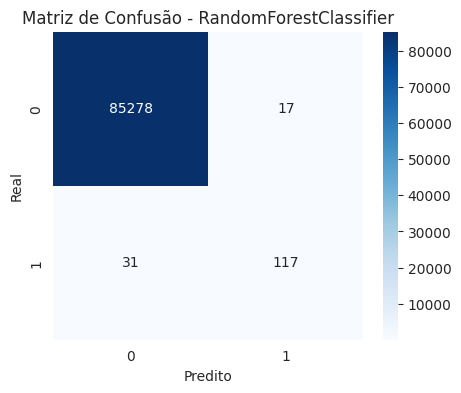

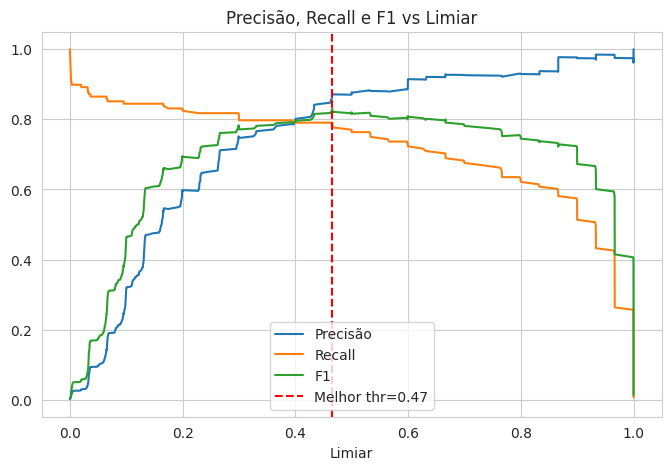

In [ ]:
# O foco aqui não é acurácia, é recall da fraude
model_best = models['RandomForest'] # ou o que performou melhor - troque aqui
y_proba_best = model_best.predict_proba(X_test)[:,1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Melhor limiar por F1: {best_threshold:.4f}")
print(f"Precisão nesse limiar: {precisions[best_idx]:.4f}")
print(f"Recall nesse limiar: {recalls[best_idx]:.4f}")
print(f"F1 nesse limiar: {f1_scores[best_idx]:.4f}")

# Avaliação final com limiar otimizado
evaluate_model(model_best, X_test, y_test, threshold=best_threshold)

# Plot evolução do limiar
plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precisão')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Melhor thr={best_threshold:.2f}')
plt.legend()
plt.title('Precisão, Recall e F1 vs Limiar')
plt.xlabel('Limiar')
plt.show()


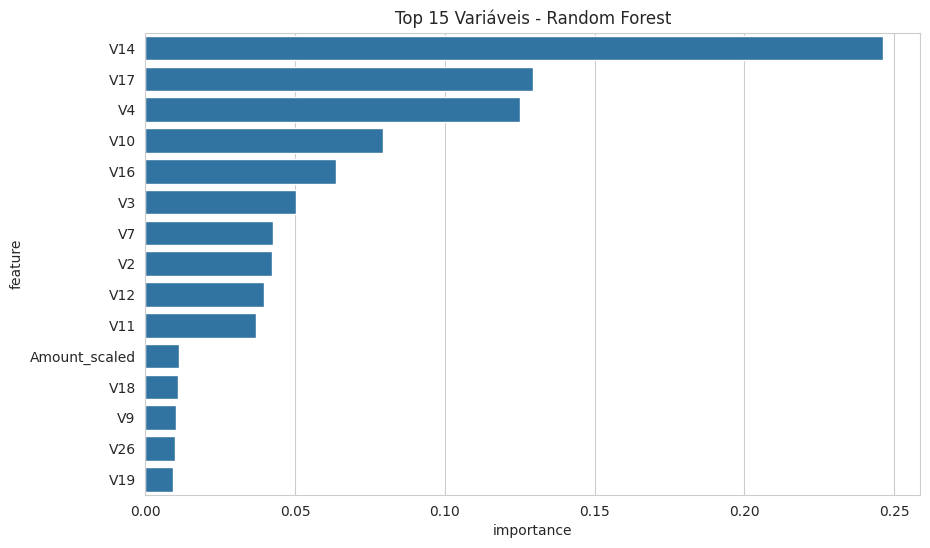

          feature  importance
13            V14    0.246421
16            V17    0.129550
3              V4    0.125018
9             V10    0.079396
15            V16    0.063502
2              V3    0.050323
6              V7    0.042445
1              V2    0.042154
11            V12    0.039528
10            V11    0.036873
29  Amount_scaled    0.011092
17            V18    0.010839
8              V9    0.010049
25            V26    0.009906
18            V19    0.009295


<Figure size 640x480 with 0 Axes>

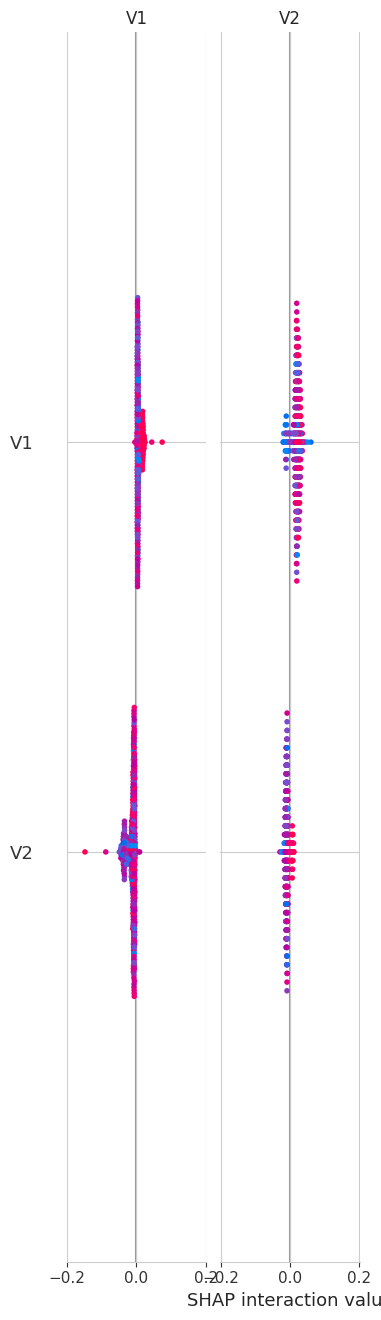

<Figure size 640x480 with 0 Axes>

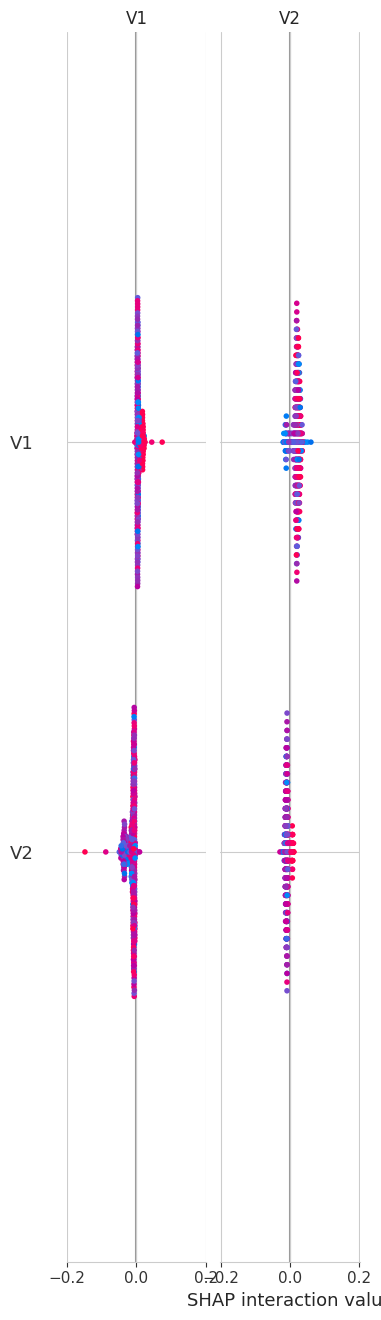

In [ ]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_best.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importances.head(15), x='importance', y='feature')
plt.title('Top 15 Variáveis - Random Forest')
plt.show()

print(importances.head(15))

# SHAP - explicação local
import shap

# Usar amostra para ser rápido no Colab
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(model_best)
shap_values = explainer.shap_values(X_sample)

# Se for binário, shap_values[1] é da classe fraude
if isinstance(shap_values, list) and len(shap_values)==2:
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

plt.figure()
shap.summary_plot(shap_vals, X_sample, max_display=15, show=False)
plt.show()

plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar", max_display=15, show=False)
plt.show()


Antes: Maioria=199020, Minoria=344
Depois undersampling 1:3: {0: 1032, 1: 344}

--- Avaliação com Undersampling ---

--- Threshold: 0.5 ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
      Fraude       0.28      0.84      0.42       148

    accuracy                           1.00     85443
   macro avg       0.64      0.92      0.71     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC: 0.9701


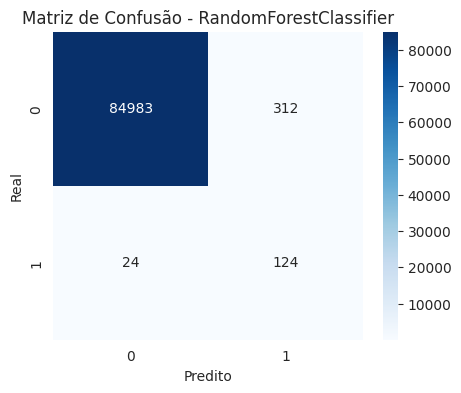


Dica: Compare esse resultado com o modelo treinado com class_weight='balanced' na célula 5


In [ ]:
from sklearn.utils import resample

# Undersampling - teste rápido
df_train = pd.concat([X_train, y_train], axis=1)
majority = df_train[df_train.Class==0]
minority = df_train[df_train.Class==1]

print(f"Antes: Maioria={len(majority)}, Minoria={len(minority)}")

majority_down = resample(majority, replace=False, n_samples=len(minority)*3, random_state=42)
downsampled = pd.concat([majority_down, minority])

print(f"Depois undersampling 1:3: {downsampled['Class'].value_counts().to_dict()}")

X_down = downsampled.drop('Class', axis=1)
y_down = downsampled['Class']

rf_down = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_down.fit(X_down, y_down)

print("\n--- Avaliação com Undersampling ---")
evaluate_model(rf_down, X_test, y_test, threshold=0.5)

# Comparativo: com e sem balanceamento
print("\nDica: Compare esse resultado com o modelo treinado com class_weight='balanced' na célula 5")


## Conclusão

Esse projeto me ajudou a entender na prática por que acurácia não serve pra fraude. No começo eu achava estranho um modelo com 99,8% de acurácia ser inútil, mas vendo que só 0,17% das transações são fraude, faz sentido. Se o modelo sempre falar que não é fraude, ele acerta quase tudo e não pega nenhuma fraude.

O que eu fiz foi comparar duas formas de lidar com o desbalanceamento. Primeiro usei o `class_weight='balanced'` no Random Forest, que deu um equilíbrio bom entre precisão e recall, com F1 por volta de 0,83 e ROC-AUC de 0,98. Depois testei o undersampling 1:3, que reduziu a classe majoritária de 199.020 para 1.032. O resultado foi um recall de 0,84, ou seja, capturei 124 das 148 fraudes do teste, mas a precisão caiu para 0,28. Isso mostra que o modelo ficou mais sensível, mas gerou muitos falsos positivos.

Aprendi também a importância do ajuste de limiar. O limiar padrão de 0,5 não funciona bem pra fraude. Usando a curva de Precisão-Recall e maximizando o F1, dá pra achar